## 1. 导包

In [1]:
from collections import deque
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from config import config
from env import GridWorld
from rollout import encode_state
from runner import DQN_Runner as ActorCriticRunner
from visualize import plot_policy, plot_training_curve

## 2. 参数配置与环境初始化

In [2]:
cfg = config(
    # 环境参数
    row_num=5,
    col_num=5,
    reward={
        "boundary": -10,
        "forbidden": -10,
        "target": 10,
        "blank": 0,
    },
    # 0=空白，1=禁止，2=目标
    grid=[
        [0, 0, 0, 0, 1],
        [0, 1, 1, 0, 2],
        [1, 0, 1, 0, 0],
        [0, 1, 2, 1, 0],
        [0, 1, 0, 0, 0],
    ],
    # 强化学习参数
    # 以下三个参数是当前 config 中的 DQN 遗留项，单步 AC 暂不使用。
    epsilon=0.1,
    batch_size=32,
    target_update_interval=100,
    gamma=0.90,
    lr=5e-4,
    value_coef=0.25,
    entropy_coef=0.1,
    max_grad_norm=0.5,
    train_iteration=100000,
    device="auto",
    # 用于统计近期表现的窗口长度
    rollout_steps=100,
    seed=123456,
    # 网络参数
    input_dim=2,
    action_dim=5,
    hidden_dim=[100, 50],
)

random.seed(cfg.rand.seed)
np.random.seed(cfg.rand.seed)
torch.manual_seed(cfg.rand.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.rand.seed)

env = GridWorld(cfg)
print(f"environment: {cfg.env.row_num} x {cfg.env.col_num}")

environment: 5 x 5


## 3. 在线 Actor–Critic 训练

每一步都使用当前 Actor 采样动作，并立即利用 TD error 更新 Actor 和 Critic；不再使用经验回放或目标网络。

In [3]:
runner = ActorCriticRunner(cfg)
state = env.reset()
history = []
recent_rewards = deque(maxlen=cfg.rollout.steps)
report_interval = max(1, cfg.rl.train_iteration // 10)

for iteration in range(1, cfg.rl.train_iteration + 1):
    encoded_state = encode_state(state, cfg)

    # 训练阶段从当前策略分布采样，而不是使用 argmax。
    action = runner.select_action(
        encoded_state,
        deterministic=False,
    )

    new_state, reward, done = env.step(action)
    encoded_new_state = encode_state(new_state, cfg)

    metrics = runner.train_step(
        state=encoded_state,
        action=action,
        reward=reward,
        new_state=encoded_new_state,
        done=done,
    )

    recent_rewards.append(reward)
    metrics["entropy"] = abs(metrics["entropy"])
    metrics["rollout_return"] = float(sum(recent_rewards))
    history.append(metrics)

    state = env.reset() if done else new_state

    if iteration == 1 or iteration % report_interval == 0:
        mean_reward = np.mean(recent_rewards)
        print(
            f"iteration={iteration:6d}  "
            f"loss={metrics['loss']:.4f}  "
            f"actor={metrics['actor_loss']:.4f}  "
            f"critic={metrics['critic_loss']:.4f}  "
            f"entropy={metrics['entropy']:.4f}  "
            f"mean_reward={mean_reward:.3f}"
        )

print(f"device: {runner.device}")

iteration=     1  loss=-0.1633  actor=-0.0025  critic=0.0000  entropy=1.6072  mean_reward=0.000
iteration= 10000  loss=9.5855  actor=-20.1139  critic=119.2807  entropy=1.2079  mean_reward=-1.200
iteration= 20000  loss=-0.1505  actor=-0.0386  critic=0.0059  entropy=1.1337  mean_reward=-0.400
iteration= 30000  loss=-0.0923  actor=0.0452  critic=0.0040  entropy=1.3853  mean_reward=-2.000
iteration= 40000  loss=-0.0871  actor=0.0438  critic=0.0050  entropy=1.3220  mean_reward=-1.500
iteration= 50000  loss=-0.0519  actor=0.0585  critic=0.0174  entropy=1.1474  mean_reward=-1.400
iteration= 60000  loss=-0.1304  actor=-0.0001  critic=0.0000  entropy=1.3029  mean_reward=-0.700
iteration= 70000  loss=-0.0661  actor=0.0542  critic=0.0107  entropy=1.2294  mean_reward=-1.000
iteration= 80000  loss=-0.0444  actor=0.0905  critic=0.0139  entropy=1.3842  mean_reward=-1.400
iteration= 90000  loss=5.0888  actor=-24.9480  critic=120.6593  entropy=1.2800  mean_reward=-0.400
iteration=100000  loss=-0.0725  

## 4. 训练结果可视化

greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):
[[1 1 1 2 2]
 [0 0 1 1 0]
 [0 4 1 1 0]
 [4 1 1 1 0]
 [4 1 1 1 0]]
critic value range: [-1.356, 10.000]
figures saved to: D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\output


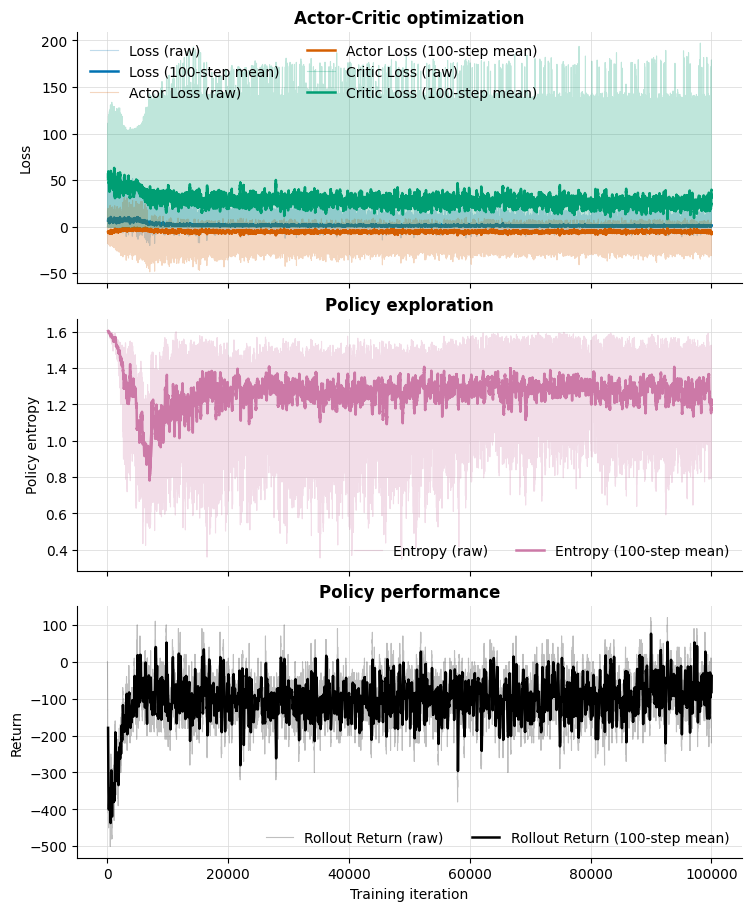

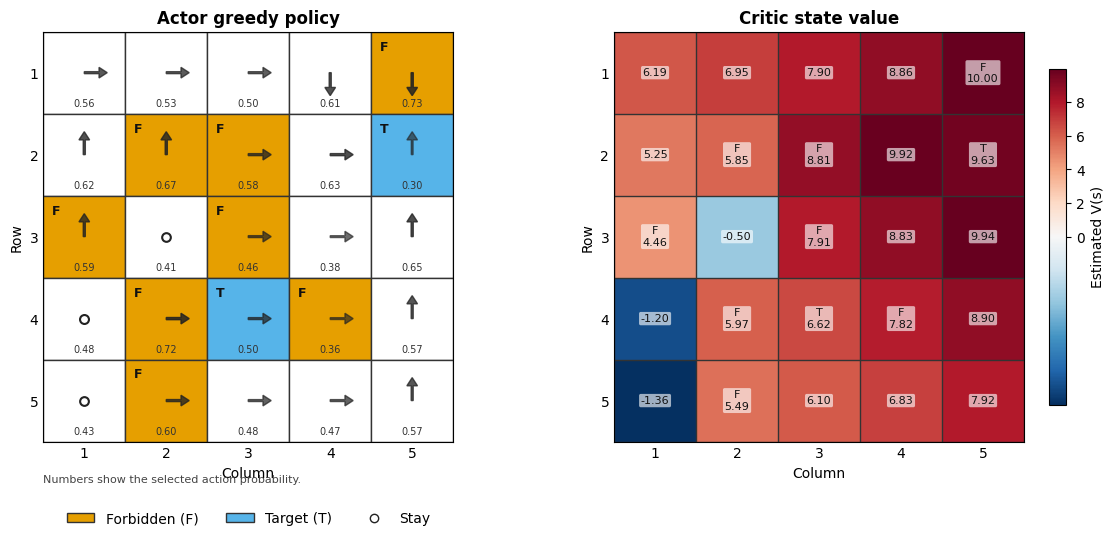

In [4]:
cwd = Path.cwd().resolve()
workspace = next(
    (path for path in (cwd, *cwd.parents) if (path / "code" / "AC").exists()),
    cwd,
)
output_dir = workspace / "output"
output_dir.mkdir(parents=True, exist_ok=True)

plot_training_curve(
    history,
    save_path=output_dir / "ac_training_metrics.png",
    smoothing_window=100,
    show=False,
)

_, _, policy, diagnostics = plot_policy(
    runner,
    cfg,
    save_path=output_dir / "ac_policy_and_value.png",
    show=False,
)

action_probabilities = diagnostics["action_probabilities"]
state_values = diagnostics["state_values"]

print("greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):")
print(policy)
print(
    f"critic value range: [{state_values.min():.3f}, "
    f"{state_values.max():.3f}]"
)
print(f"figures saved to: {output_dir}")
plt.show()